# TECHMIND - Organizacion Inteligente del Conocimiento Tecnico
## Hackathon ONE (Oracle Next Education + Alura + NoCountry) - Grupo G9
### Rol: Equipo de Ciencia de Datos


# **1. Preparación del entorno de desarrollo**

---
## Instalar librerias necesarias


In [ ]:
# Instalar librerias que no vienen por defecto en Colab
!pip install joblib skl2onnx onnxruntime -q

print("Librerias instaladas correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 26.5 MB/s eta 0:00:00
Librerias instaladas correctamente.


---
## Importar las librerias



In [ ]:
import os
import re
import joblib
import pandas as pd
import numpy as np
import logging
import json
from pathlib import Path
import shutil
from google.colab import files

# Librerias para hacer graficos
import matplotlib.pyplot as plt
import seaborn as sns

# Modulos de Scikit-Learn (Machine Learning)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer

# skl2onnx: convierte modelos de scikit-learn a formato ONNX
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import StringTensorType

# Configuracion de graficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

# Configuracion de Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("COMPLETADO: Librerias cargadas correctamente.")

COMPLETADO: Librerias cargadas correctamente.


---
## Cargar el dataset


**Importante:** En Google Colab, debes subir el archivo manualmente en la carpeta de /content. De no ser así, hacer lo siguiente:
1. Ejecuta la siguiente celda
2. Haz clic en "Choose Files" (Seleccionar archivos)
3. Selecciona el archivo `dataset_hackaton_lenguajes_traducido.csv`

In [ ]:
nombre_archivo = 'dataset_hackaton_lenguajes_traducido.csv'

if not os.path.exists(nombre_archivo):
    print(f"Por favor, selecciona el archivo '{nombre_archivo}'")
    archivo_subido = files.upload()
    nombre_archivo = list(archivo_subido.keys())[0]

print(f"\nArchivo listo para procesamiento: {nombre_archivo}")
print(f"Tamaño: {os.path.getsize(nombre_archivo) / (1024 * 1024):.2f} MB")

Por favor, selecciona el archivo 'dataset_hackaton_lenguajes_traducido.csv'


Saving dataset_hackaton_lenguajes_traducido.csv to dataset_hackaton_lenguajes_traducido.csv

Archivo listo para procesamiento: dataset_hackaton_lenguajes_traducido.csv
Tamaño: 16.08 MB


In [ ]:
# ==============================================================================
# GITHUB
# ==============================================================================

ruta_local = '/content/dataset_hackaton_lenguajes_traducido.csv'
url_github = 'https://raw.githubusercontent.com/No-Country-simulation/G9-LATAM-Team-73/main/data/raw/dataset_hackaton_lenguajes_traducido.csv'

print(f"Intentando cargar dataset desde la ruta local: {ruta_local}")

try:
    if not os.path.exists(ruta_local):
        raise FileNotFoundError("El archivo no se encuentra en el entorno local.")

    try:
        df = pd.read_csv(ruta_local, encoding='utf-8', on_bad_lines='skip', engine='python')
    except UnicodeDecodeError:
        df = pd.read_csv(ruta_local, encoding='latin-1', on_bad_lines='skip', engine='python')
    print("Carga local completada exitosamente.")

except Exception as e:
    print(f"No se pudo cargar el archivo local ({e}).")
    print("Iniciando descarga alternativa desde el repositorio de GitHub...")

    try:
        df = pd.read_csv(url_github, encoding='utf-8', on_bad_lines='skip', engine='python')
    except UnicodeDecodeError:
        df = pd.read_csv(url_github, encoding='latin-1', on_bad_lines='skip', engine='python')
    print("Dataset descargado y cargado exitosamente desde GitHub.")

print(f"\nTotal de registros iniciales cargados: {len(df)}")

Intentando cargar dataset desde la ruta local: /content/dataset_hackaton_lenguajes_traducido.csv
Carga local completada exitosamente.

Total de registros iniciales cargados: 5524


# **2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)**

## Exploración de datos

---
### Leer el dataset



In [ ]:
ruta_dataset = nombre_archivo

try:
    df = pd.read_csv(ruta_dataset, encoding='utf-8', on_bad_lines='skip')
    print("Archivo leído exitosamente con codificación UTF-8.")
except UnicodeDecodeError:
    df = pd.read_csv(ruta_dataset, encoding='latin-1', on_bad_lines='skip')
    print("Archivo leído exitosamente con codificación latin-1.")

print(f"\nTotal de registros cargados: {len(df)}")
print(f"Total de columnas: {len(df.columns)}")

Archivo leído exitosamente con codificación latin-1.

Total de registros cargados: 5524
Total de columnas: 10


### Inspección de los datos



In [ ]:
print("=== INFORMACIÓN DEL DATASET ===")
print(f"Dimensiones iniciales: {df.shape[0]} filas, {df.shape[1]} columnas\n")

# Quedarnos solo con las columnas en español de interés
cols_espanol = ['id', 'titulo', 'subtitulo', 'descripcion', 'categoria', 'lenguaje']
df = df[[c for c in cols_espanol if c in df.columns]].copy()

# Verificar duplicados exactos
duplicados = df.duplicated().sum()
print(f"Filas completamente duplicadas: {duplicados}")
if duplicados > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("-> Duplicados eliminados.")

df.info()

=== INFORMACIÓN DEL DATASET ===
Dimensiones iniciales: 5524 filas, 10 columnas

Filas completamente duplicadas: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5524 entries, 0 to 5523
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           5524 non-null   object
 1   titulo       5522 non-null   object
 2   subtitulo    2966 non-null   object
 3   descripcion  5522 non-null   object
 4   categoria    1142 non-null   object
 5   lenguaje     1142 non-null   object
dtypes: object(6)
memory usage: 259.1+ KB


## Limpieza y preparación de datos

In [ ]:
# ==============================================================================
# TRATAMIENTO DE NULOS Y NORMALIZACIÓN DE TEXTO
# ==============================================================================
# 1. Diagnóstico de nulos inicial
print("=== RESUMEN DE VALORES NULOS ===")
display(df.isnull().sum().to_frame(name='Total Nulos'))

# 2. Imputación de vacíos en columnas de texto
cols_texto = ['titulo', 'subtitulo', 'descripcion']
for col in cols_texto:
    if col in df.columns:
        df[col] = df[col].fillna('')

# 3. Normalización y filtrado explícito de la variable objetivo (lenguaje/categoría)
# Mapeo de normalización para asegurar etiquetas homogéneas y limpias
mapa_lenguajes = {
    # Lenguajes presentes en tu dataset (Evita borrar registros)
    'c': 'C',
    'c++': 'C++',
    'cpp': 'C++',
    'c#': 'C#',
    'csharp': 'C#',
    'go': 'Go',
    'golang': 'Go',
    'java': 'Java',
    'javascript': 'JavaScript',
    'js': 'JavaScript',
    'python': 'Python',
    'py': 'Python',
    'sql': 'SQL',
    'php': 'PHP',
    'css': 'CSS',
    'html': 'HTML',
    'html/css': 'HTML/CSS',
    'haskell': 'Haskell',
    'perl': 'Perl',
    'matlab': 'MATLAB',
    'typescript': 'TypeScript',
    'ts': 'TypeScript',
    'ruby': 'Ruby',
    'rb': 'Ruby',
    'swift': 'Swift',
    'kotlin': 'Kotlin',
    'kt': 'Kotlin',
    'rust': 'Rust',
    'rs': 'Rust',
    'r': 'R',
    'bash': 'Shell',
    'shell': 'Shell'
}

# Limpiar espacios y estandarizar
if 'lenguaje' in df.columns:
    df['lenguaje_limpio'] = df['lenguaje'].astype(str).str.strip().str.lower()
    df['lenguaje_limpio'] = df['lenguaje_limpio'].map(mapa_lenguajes)

    # Eliminar registros sin etiqueta válida objetivo
    df = df.dropna(subset=['lenguaje_limpio']).copy().reset_index(drop=True)
    # Mantener sincronizada la columna 'lenguaje'
    df['lenguaje'] = df['lenguaje_limpio']

# Si tu target principal para la clasificación sigue siendo 'categoria', realizamos la limpieza análoga
if 'categoria' in df.columns:
    df = df.dropna(subset=['categoria']).copy().reset_index(drop=True)

# 4. Creación y Normalización del texto consolidado
df['texto_completo'] = (df['titulo'] + " " + df['subtitulo'] + " " + df['descripcion']).str.strip()

def normalizar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto)  # Eliminar URLs
    texto = re.sub(r'[^\w\s\u00C0-\u00FF]', ' ', texto)     # Conservar letras y tildes
    texto = re.sub(r'\s+', ' ', texto).strip()             # Espacios extra
    return texto

df['texto_limpio'] = df['texto_completo'].apply(normalizar_texto)

print(f"\nProcesamiento completado. Registros listos para entrenamientos: {len(df)}")

=== RESUMEN DE VALORES NULOS ===


,Total Nulos
id,0
titulo,2
subtitulo,2558
descripcion,2
categoria,4382
lenguaje,4382



Procesamiento completado. Registros listos para entrenamientos: 1142


## Clase negativa: texto "no tecnico"

El dataset original no tenia ninguna categoria para texto sin relacion con tecnologia. Un clasificador cerrado de 3 clases (backend/frontend/full stack) siempre elige una de esas 3 aunque el texto sea basura o completamente ajeno al dominio tecnico. Se agrega una clase sintetica "no tecnico" (texto generico no tecnico + gibberish) para que el modelo aprenda a reconocer esos casos.

In [ ]:
import random

def generar_clase_no_tecnico(seed=42, n_generico=95, n_gibberish=55):
    rnd = random.Random(seed)

    temas = [
        ("Receta de cocina", [
            "Para preparar {plato} se necesita {ingrediente1}, {ingrediente2} y {ingrediente3}.",
            "El secreto de un buen {plato} esta en dejar reposar {ingrediente1} antes de cocinar.",
            "Esta receta de {plato} lleva {ingrediente1}, {ingrediente2}, sal y un poco de {ingrediente3}.",
        ]),
        ("El clima", [
            "Se espera un dia {clima} con temperaturas de {numero} grados en la zona {lugar}.",
            "El pronostico indica lluvias en {lugar} durante {momento} de esta semana.",
            "La temperatura minima en {lugar} sera de {numero} grados durante {momento}.",
        ]),
        ("Poema", [
            "Tus {parte_cuerpo} brillan como estrellas cuando el {momento} llega.",
            "El amor que siento por ti crece cada {momento} como la marea.",
            "Bajo la luna de {lugar} escribo versos para quien amo.",
        ]),
        ("Resena de pelicula", [
            "La pelicula tiene una trama {adjetivo} con actuaciones {adjetivo2} de principio a fin.",
            "El director logro un {adjetivo} equilibrio entre drama y comedia en esta cinta.",
            "Los efectos especiales son {adjetivo} pero el guion resulta {adjetivo2}.",
        ]),
        ("Lista de compras", [
            "Necesito comprar {ingrediente1}, {ingrediente2}, {ingrediente3} y papel higienico.",
            "En el supermercado hay que llevar {ingrediente1}, {ingrediente2} y detergente.",
        ]),
        ("Historia de viaje", [
            "El verano pasado viajamos a {lugar} y disfrutamos del sol y la playa.",
            "Durante el viaje a {lugar} probamos comidas tipicas y conocimos gente {adjetivo}.",
        ]),
        ("Deportes", [
            "El equipo local gano el partido por {numero} goles gracias a una jugada {adjetivo}.",
            "El torneo de {lugar} tuvo un final {adjetivo} entre los dos mejores equipos.",
        ]),
        ("Mascotas", [
            "Mi {mascota} es muy {adjetivo2} y le encanta jugar en el parque todas las tardes.",
            "Adoptamos un {mascota} hace {numero} meses y ya forma parte de la familia.",
        ]),
        ("Chistes", [
            "Por que el {objeto} esta triste? porque tiene demasiados problemas sin resolver.",
            "Que le dijo un {objeto} a otro? nos vemos en {lugar} la proxima semana.",
        ]),
        ("Jardineria", [
            "Para cuidar las plantas de interior hay que regarlas cada {numero} dias con luz indirecta.",
            "El jardin de {lugar} necesita abono y riego constante durante {momento}.",
        ]),
    ]

    plato = ["arroz con pollo", "pasta al pesto", "tarta de manzana", "sopa de verduras", "pan casero"]
    ingrediente = ["cebolla", "tomate", "harina", "leche", "huevos", "azucar", "sal", "aceite", "pollo", "arroz"]
    clima = ["soleado", "nublado", "lluvioso", "ventoso", "calido"]
    lugar = ["la costa", "la montana", "el centro", "el valle", "la ciudad", "el pueblo"]
    momento = ["la manana", "la tarde", "la noche", "el fin de semana", "el invierno", "el verano"]
    parte_cuerpo = ["ojos", "manos", "sonrisa"]
    adjetivo = ["increible", "aburrida", "emocionante", "confusa", "sorprendente", "lenta"]
    adjetivo2 = ["carinoso", "juguet\u00f3n", "tranquilo", "energico", "amigable"]
    mascota = ["perro", "gato", "loro", "conejo", "hamster"]
    objeto = ["libro", "reloj", "telefono", "zapato"]
    numero = ["dos", "tres", "cuatro", "cinco", "quince", "veinte"]

    valores = dict(
        plato=plato, ingrediente1=ingrediente, ingrediente2=ingrediente, ingrediente3=ingrediente,
        clima=clima, lugar=lugar, momento=momento, parte_cuerpo=parte_cuerpo,
        adjetivo=adjetivo, adjetivo2=adjetivo2, mascota=mascota, objeto=objeto, numero=numero,
    )

    filas = []
    contador = 0
    while contador < n_generico:
        tema, plantillas = rnd.choice(temas)
        plantilla = rnd.choice(plantillas)
        placeholders = re.findall(r"\{(\w+)\}", plantilla)
        texto = plantilla.format(**{p: rnd.choice(valores[p]) for p in placeholders})
        filas.append({"titulo": tema, "subtitulo": "", "descripcion": texto})
        contador += 1

    consonantes = "bcdfghjklmnpqrstvwxyz"
    vocales = "aeiou"
    simbolos = list("!@#$%^&*()_+-=[]{}|;:,.<>?/")

    def gibberish_teclado(n_palabras):
        palabras = []
        for _ in range(n_palabras):
            largo = rnd.randint(3, 10)
            palabras.append("".join(rnd.choice(consonantes + vocales) for _ in range(largo)))
        return " ".join(palabras)

    def gibberish_simbolos():
        return " ".join(
            "".join(rnd.choice(simbolos + list("0123456789")) for _ in range(rnd.randint(3, 8)))
            for _ in range(rnd.randint(4, 8))
        )

    def letra_repetida():
        letra = rnd.choice(consonantes + vocales)
        return letra * rnd.randint(40, 120)

    generadores = [
        lambda: gibberish_teclado(rnd.randint(4, 12)),
        lambda: gibberish_simbolos(),
        lambda: letra_repetida(),
        lambda: (gibberish_teclado(rnd.randint(3, 6)) + " " + gibberish_simbolos()),
    ]

    for i in range(n_gibberish):
        texto = rnd.choice(generadores)()
        filas.append({
            "titulo": "sin titulo" if i % 2 == 0 else gibberish_teclado(2),
            "subtitulo": "",
            "descripcion": texto,
        })

    df_no_tecnico = pd.DataFrame(filas)
    df_no_tecnico["categoria"] = "no tecnico"
    df_no_tecnico["lenguaje"] = "N/A"
    df_no_tecnico["id"] = [f"synthetic-{i}" for i in range(len(df_no_tecnico))]
    return df_no_tecnico[["id", "titulo", "subtitulo", "descripcion", "categoria", "lenguaje"]]


df_no_tecnico = generar_clase_no_tecnico()
print(f"Filas sinteticas generadas: {len(df_no_tecnico)}")
df = pd.concat([df, df_no_tecnico], ignore_index=True)
print(f"Total de filas tras agregar clase 'no tecnico': {len(df)}")


## Ejemplos reales adicionales: frameworks poco representados

El dataset original casi no menciona frameworks frontend/full stack modernos (Angular, MERN, Axios, HttpClient, Django+React). Al no existir esas palabras en el vocabulario TF-IDF, el modelo quedaba sin señal real para esos textos y su probabilidad caia casi al azar entre las 4 categorias (confirmado en produccion tras el primer reentreno). Se agregan ejemplos reales (no plantillas) que cubren explicitamente esas palabras clave.

In [ ]:
def generar_ejemplos_frameworks_reales():
    filas = [
        ("Introduccion a Angular desde cero", "", "Aprende Angular y TypeScript para construir interfaces de usuario modernas. El curso cubre componentes, modulos, directivas, pipes y el enrutador de Angular.", "frontend", "TypeScript"),
        ("Formularios reactivos en Angular", "", "Domina los formularios reactivos de Angular con validaciones sincronas y asincronas, y consume una API REST usando HttpClient para enviar y recibir datos del servidor.", "frontend", "TypeScript"),
        ("Angular avanzado: servicios e inyeccion de dependencias", "", "Este curso ensena a crear servicios en Angular, inyeccion de dependencias, y comunicacion con el backend mediante HttpClient y observables de RxJS.", "frontend", "TypeScript"),
        ("Consumo de APIs REST con HttpClient en Angular", "", "Aprende a usar el modulo HttpClient de Angular para realizar peticiones GET, POST, PUT y DELETE contra una API REST, manejar errores y mostrar los datos en la interfaz.", "frontend", "TypeScript"),
        ("Componentes y directivas personalizadas en Angular", "", "Construye componentes reutilizables y directivas personalizadas en Angular, junto con el manejo de estado local del componente y comunicacion entre componentes padre e hijo.", "frontend", "TypeScript"),
        ("Vue.js para principiantes", "", "Curso practico de Vue.js donde aprenderas a crear componentes, manejar el estado con Vuex y consumir APIs externas usando Axios desde el frontend.", "frontend", "JavaScript"),
        ("Peticiones HTTP con Axios en aplicaciones frontend", "", "Aprende a usar la libreria Axios para consumir APIs REST desde React, Vue o cualquier aplicacion JavaScript del lado del cliente, incluyendo interceptores y manejo de errores.", "frontend", "JavaScript"),
        ("Hooks avanzados en React", "", "Explora los hooks de React como useEffect, useContext y hooks personalizados para manejar el estado y el ciclo de vida de los componentes de la interfaz de usuario.", "frontend", "JavaScript"),
        ("Maquetacion moderna con CSS Grid y Flexbox", "", "Aprende a maquetar interfaces responsive modernas usando CSS Grid y Flexbox, junto con buenas practicas de diseno adaptable para distintos dispositivos.", "frontend", "CSS"),
        ("Angular Material: componentes de interfaz listos para usar", "", "Este curso muestra como integrar Angular Material en tu aplicacion Angular para crear interfaces de usuario consistentes con componentes prediseñados.", "frontend", "TypeScript"),
        ("Aplicacion full stack con el stack MERN", "", "Construye una aplicacion completa usando MongoDB como base de datos, Express como framework de backend, React para la interfaz de usuario y Node.js como entorno de ejecucion del servidor.", "full stack", "JavaScript"),
        ("API REST con Express y consumo desde React", "", "Aprende a crear una API REST con Node.js y Express, conectarla a una base de datos MongoDB, y consumirla desde una aplicacion frontend hecha en React usando Axios.", "full stack", "JavaScript"),
        ("Autenticacion JWT en una aplicacion MERN", "", "Implementa autenticacion con JWT en una aplicacion full stack MERN: backend con Express y MongoDB, y frontend en React que envia las credenciales usando Axios.", "full stack", "JavaScript"),
        ("Full stack con Django REST Framework y React", "", "Backend construido con Django REST Framework en Python conectado a un frontend en React que consume la API mediante Axios, con autenticacion basada en tokens.", "full stack", "Python"),
        ("Aplicacion full stack con Django y Vue.js", "", "Aprende a construir una aplicacion completa con Django REST Framework como backend en Python y Vue.js como frontend, comunicandose a traves de una API REST.", "full stack", "Python"),
        ("Despliegue de una aplicacion MERN en produccion", "", "Aprende a desplegar una aplicacion full stack MERN (MongoDB, Express, React, Node.js) en un servidor de produccion usando Docker y variables de entorno.", "full stack", "JavaScript"),
        ("Del backend Express al frontend Angular", "", "Construye una aplicacion full stack conectando un backend en Node.js con Express a un frontend en Angular que consume la API mediante HttpClient.", "full stack", "TypeScript"),
        ("Proyecto full stack con Express, MongoDB y React", "", "Este proyecto integra un backend en Express con base de datos MongoDB y un frontend en React que se comunica con la API usando Axios para operaciones CRUD.", "full stack", "JavaScript"),
        ("Full stack con Django, PostgreSQL y React", "", "Aprende a construir una aplicacion full stack con Django y PostgreSQL en el backend, y React en el frontend consumiendo la API REST con Axios.", "full stack", "Python"),
        ("Node.js, Express y MongoDB: API REST para tu frontend", "", "Crea una API REST completa con Node.js, Express y MongoDB, pensada para ser consumida por cualquier frontend moderno como React, Vue o Angular mediante Axios.", "full stack", "JavaScript"),
        ("Backend con Django REST Framework", "", "Aprende a construir una API REST con Django REST Framework en Python, incluyendo serializadores, vistas basadas en clases y autenticacion.", "backend", "Python"),
        ("API REST con Express y Node.js", "", "Construye una API REST desde cero usando Node.js y Express, con rutas, middlewares personalizados y conexion a una base de datos MongoDB.", "backend", "JavaScript"),
        ("Servicios backend con Django y bases de datos relacionales", "", "Este curso cubre la creacion de servicios backend con Django, modelos de base de datos relacionales y consultas eficientes con el ORM de Django.", "backend", "Python"),
        ("Microservicios en Express con arquitectura modular", "", "Aprende a estructurar una aplicacion backend en Express de forma modular, separando rutas, controladores y servicios para facilitar el mantenimiento.", "backend", "JavaScript"),
    ]

    df_frameworks = pd.DataFrame(filas, columns=["titulo", "subtitulo", "descripcion", "categoria", "lenguaje"])
    df_frameworks["id"] = [f"framework-{i}" for i in range(len(df_frameworks))]
    return df_frameworks[["id", "titulo", "subtitulo", "descripcion", "categoria", "lenguaje"]]


df_frameworks = generar_ejemplos_frameworks_reales()
print(f"Filas reales de frameworks agregadas: {len(df_frameworks)}")
df = pd.concat([df, df_frameworks], ignore_index=True)
print(f"Total de filas tras agregar frameworks: {len(df)}")


In [ ]:
# --- Mostrar estadisticas basicas de los textos ---
print("ESTADISTICAS BASICAS DE LOS TEXTOS:")

longitud_titulos = df['titulo'].fillna('').astype(str).apply(len)
longitud_descripciones = df['descripcion'].fillna('').astype(str).apply(len)

print(f"   Titulos:")
print(f"      - Longitud promedio: {longitud_titulos.mean():.0f} caracteres")
print(f"      - Titulo mas corto:  {longitud_titulos.min()} caracteres")
print(f"      - Titulo mas largo:  {longitud_titulos.max()} caracteres")
print(f"   Descripciones:")
print(f"      - Longitud promedio: {longitud_descripciones.mean():.0f} caracteres")
print(f"      - Descripcion mas corta:  {longitud_descripciones.min()} caracteres")
print(f"      - Descripcion mas larga:  {longitud_descripciones.max()} caracteres")


ESTADISTICAS BASICAS DE LOS TEXTOS:
   Titulos:
      - Longitud promedio: 42 caracteres
      - Titulo mas corto:  3 caracteres
      - Titulo mas largo:  244 caracteres
   Descripciones:
      - Longitud promedio: 1394 caracteres
      - Descripcion mas corta:  8 caracteres
      - Descripcion mas larga:  3424 caracteres


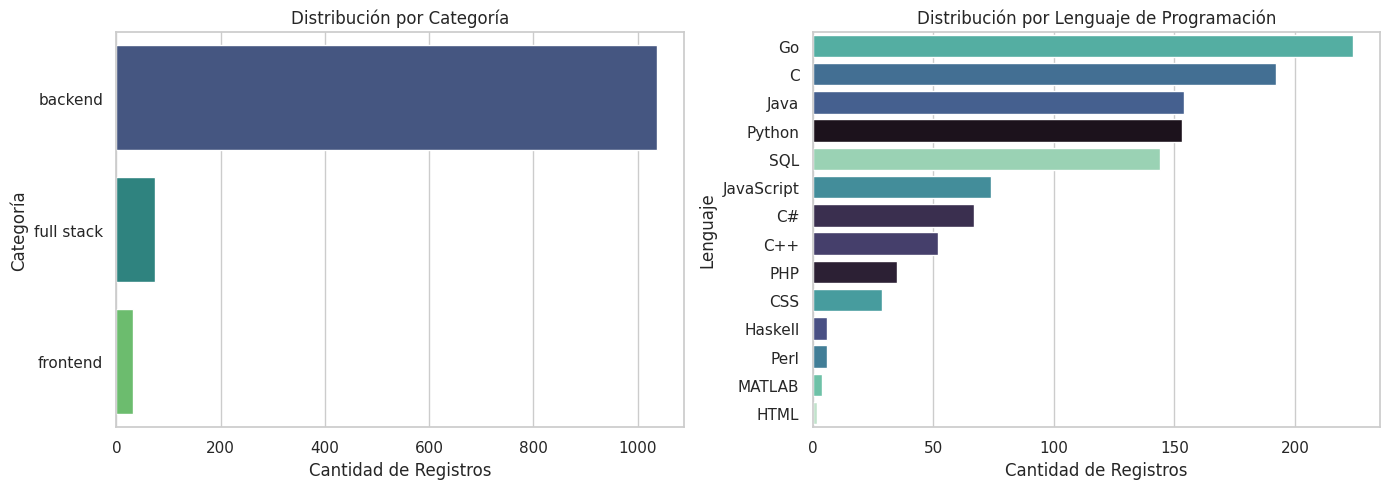

In [ ]:
# ==============================================================================
# CATEGORÍAS Y LENGUAJES DISPONIBLES
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GRAFICO 1: Distribución de Categorías
if 'categoria' in df.columns and df['categoria'].nunique() > 0:
    order_cat = df['categoria'].value_counts().index
    sns.countplot(
        data=df,
        y='categoria',
        order=order_cat,
        palette='viridis',
        hue='categoria',
        legend=False,
        ax=axes[0]
    )
    axes[0].set_title('Distribución por Categoría')
    axes[0].set_xlabel('Cantidad de Registros')
    axes[0].set_ylabel('Categoría')

# GRAFICO 2: Distribución de Lenguajes
if 'lenguaje' in df.columns and df['lenguaje'].nunique() > 0:
    order_leng = df['lenguaje'].value_counts().index
    sns.countplot(
        data=df,
        y='lenguaje',
        order=order_leng,
        palette='mako',
        hue='lenguaje',
        legend=False,
        ax=axes[1]
    )
    axes[1].set_title('Distribución por Lenguaje de Programación')
    axes[1].set_xlabel('Cantidad de Registros')
    axes[1].set_ylabel('Lenguaje')

plt.tight_layout()
plt.show()

## Visualización y análisis de datos



GENERANDO GRAFICOS EXPLORATORIOS...

Generando gráfico: Top 10 Categorías...


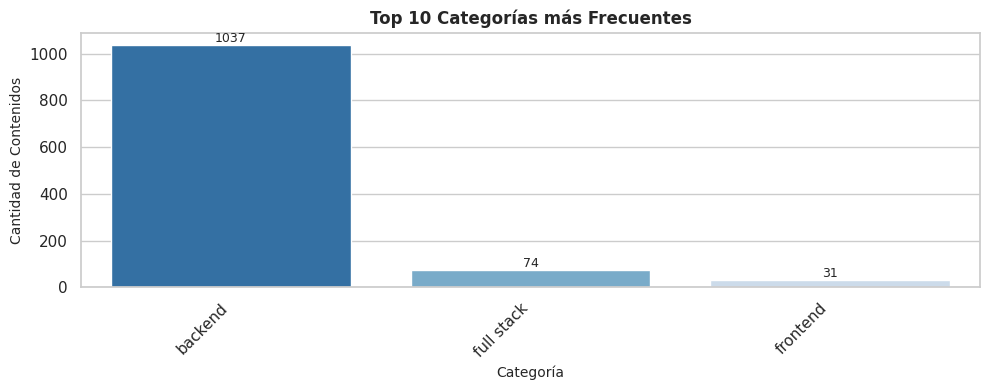

Gráfico de categorías generado.


In [ ]:
print("GENERANDO GRAFICOS EXPLORATORIOS...")

# Listado de valores basura a ignorar en las gráficas
valores_invalidos = ['', 'nan', 'none', '#valor!', 'null', 'undefined']

# 1. Obtener series limpias directamente del DataFrame 'df'
cat_series = df['categoria'].dropna().astype(str).str.strip().str.lower()
len_series = df['lenguaje'].dropna().astype(str).str.strip().str.lower()

cat_para_grafico = cat_series[~cat_series.isin(valores_invalidos)]
len_para_grafico = len_series[~len_series.isin(valores_invalidos)]

# GRAFICO 3: Top 10 Categorias
print("\nGenerando gráfico: Top 10 Categorías...")
top_categorias = cat_para_grafico.value_counts().head(10)

plt.figure(figsize=(10, 4))
grafico_cat = sns.barplot(
    x=top_categorias.index,
    y=top_categorias.values,
    hue=top_categorias.index,
    palette="Blues_r",
    legend=False
)
plt.title("Top 10 Categorías más Frecuentes", fontsize=12, fontweight='bold')
plt.xlabel("Categoría", fontsize=10)
plt.ylabel("Cantidad de Contenidos", fontsize=10)
plt.xticks(rotation=45, ha='right')

for barra in grafico_cat.patches:
    if barra.get_height() > 0:
        grafico_cat.annotate(
            f'{int(barra.get_height())}',
            (barra.get_x() + barra.get_width() / 2., barra.get_height()),
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.show()
print("Gráfico de categorías generado.")

Generando grafico: Top 10 Lenguajes de Programacion...


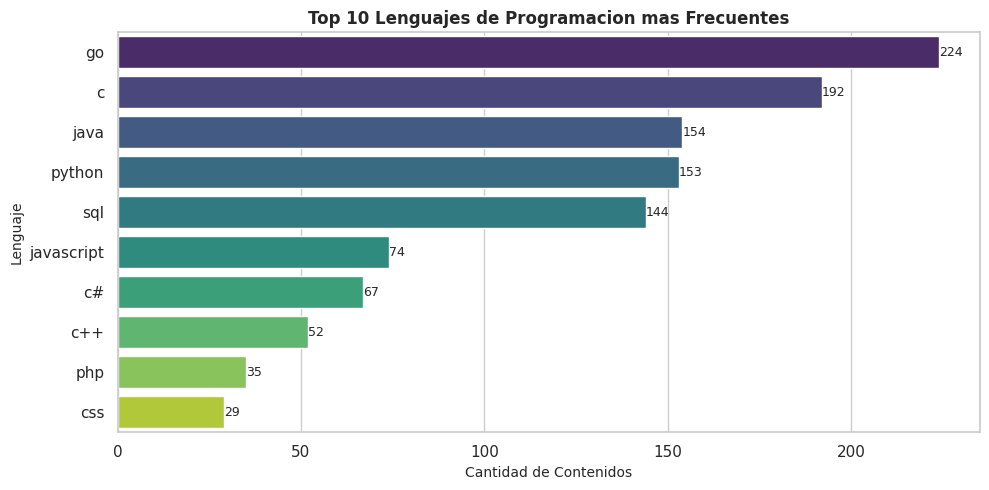

Grafico de lenguajes generado.


In [ ]:
# GRÁFICO 4: Top 10 Lenguajes de Programación
print("Generando grafico: Top 10 Lenguajes de Programacion...")
top_lenguajes = len_para_grafico.value_counts().head(10)

plt.figure(figsize=(10, 5))
grafico_len = sns.barplot(
    y=top_lenguajes.index,
    x=top_lenguajes.values,
    hue=top_lenguajes.index,
    palette="viridis",
    legend=False
)
plt.title("Top 10 Lenguajes de Programacion mas Frecuentes", fontsize=12, fontweight='bold')
plt.xlabel("Cantidad de Contenidos", fontsize=10)
plt.ylabel("Lenguaje", fontsize=10)

for barra in grafico_len.patches:
    if barra.get_width() > 0:
        grafico_len.annotate(
            f'{int(barra.get_width())}',
            (barra.get_width(), barra.get_y() + barra.get_height() / 2.),
            ha='left', va='center', fontsize=9
        )
plt.tight_layout()
plt.show()
print("Grafico de lenguajes generado.")

Generando grafico: Distribucion de palabras en los textos...


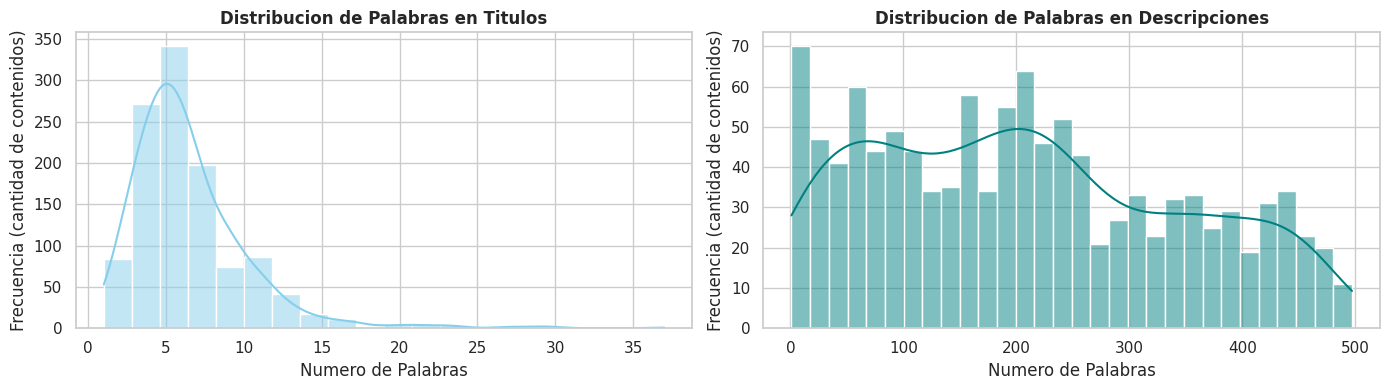

Grafico de distribucion de palabras generado.


In [ ]:
# GRÁFICOS 5 Y 6: Distribucion de palabras en titulos y descripciones
print("Generando grafico: Distribucion de palabras en los textos...")

df_temp = df.copy()
df_temp['palabras_titulo'] = df_temp['titulo'].fillna('').astype(str).apply(lambda x: len(x.split()))
df_temp['palabras_descripcion'] = df_temp['descripcion'].fillna('').astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df_temp['palabras_titulo'], kde=True, ax=axes[0], color='skyblue', bins=20)
axes[0].set_title("Distribucion de Palabras en Titulos", fontweight='bold')
axes[0].set_xlabel("Numero de Palabras")
axes[0].set_ylabel("Frecuencia (cantidad de contenidos)")

sns.histplot(
    df_temp['palabras_descripcion'][df_temp['palabras_descripcion'] < 500],
    kde=True, ax=axes[1], color='teal', bins=30
)
axes[1].set_title("Distribucion de Palabras en Descripciones", fontweight='bold')
axes[1].set_xlabel("Numero de Palabras")
axes[1].set_ylabel("Frecuencia (cantidad de contenidos)")

plt.tight_layout()
plt.show()
print("Grafico de distribucion de palabras generado.")

# **3. PREPARACIÓN DE DATOS PARA EL MODELADO**

## Limpieza profunda de los textos para el modelado

Esta funcion prepara los textos para que el modelo pueda entenderlos. Convierte todo a minusculas, elimina signos de puntuacion, numeros y espacios de mas.

Ademas, definimos una lista de **Stop Words en espanol** (palabras muy comunes como "el", "la", "que", "de") que no aportan significado al modelo. Al eliminarlas, el modelo se enfoca en las palabras realmente importantes.

In [ ]:
# Lista de Stop Words en espanol (palabras muy comunes sin valor semantico)
# El modelo ignorara estas palabras para enfocarse en las realmente importantes
STOP_WORDS_ESPANOL = [
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por',
    'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'mas', 'pero',
    'sus', 'le', 'ya', 'o', 'este', 'si', 'porque', 'esta', 'entre', 'cuando',
    'muy', 'sin', 'sobre', 'tambien', 'me', 'hasta', 'hay', 'donde', 'quien',
    'todo', 'solo', 'que', 'ella', 'era', 'son', 'dos', 'tiene', 'han',
    'puede', 'ser', 'fue', 'tan', 'como', 'cada', 'ese', 'si', 'desde', 'nos',
    'ni', 'caso', 'sino', 'este', 'tener', 'hacer', 'otros', 'otra', 'poco',
    'mismo', 'mismos', 'misma', 'mismas', 'gran', 'esta', 'esto', 'ante',
    'ellos', 'ellas', 'ello', 'unas', 'unos', 'voy', 'vas', 'va', 'vamos',
    'van', 'vaya', 'vayas', 'vayamos', 'vayan', 'he', 'has', 'ha', 'hemos',
    'han', 'haya', 'hayas', 'hayamos', 'hayan', 'estoy', 'estas', 'esta',
    'estamos', 'estan', 'este', 'estes', 'estemos', 'esten', 'sere', 'seras',
    'sera', 'seremos', 'seran', 'sea', 'seas', 'seamos', 'sean', 'habia',
    'habias', 'habia', 'habiamos', 'habian', 'habra', 'habras', 'habra',
    'habremos', 'habran', 'hubo', 'hubiste', 'hubo', 'hubimos', 'hubieron',
    'hubiera', 'hubieras', 'hubiera', 'hubieramos', 'hubieran', 'hubiese',
    'hubieses', 'hubiese', 'hubiesemos', 'hubiesen', 'tuviera', 'tuvieras',
    'tuviera', 'tuvieramos', 'tuvieran', 'tuviese', 'tuvieses', 'tuviese',
    'tuviesemos', 'tuviesen', 'tenga', 'tengas', 'tenga', 'tengamos', 'tengan',
    'tendre', 'tendras', 'tendra', 'tendremos', 'tendran', 'tengo', 'tienes',
    'tiene', 'tenemos', 'tienen', 'tuve', 'tuviste', 'tuvo', 'tuvimos',
    'tuvieron', 'hago', 'haces', 'hace', 'hacemos', 'hacen', 'hice', 'hiciste',
    'hizo', 'hicimos', 'hicieron', 'haria', 'harias', 'haria', 'hariamos',
    'harian', 'hagan', 'hagas', 'haga', 'hagamos', 'hagan'
]

print(f"Stop Words en espanol cargadas: {len(STOP_WORDS_ESPANOL)} palabras.")


def limpiar_texto(texto):

    if not isinstance(texto, str):
        return ""

    texto = texto.lower()
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto)  # Eliminar URLs/enlaces
    texto = re.sub(r'[^\w\s\u00C0-\u00FF]', ' ', texto)     # Conservar letras, números, tildes y ñ
    texto = re.sub(r'\s+', ' ', texto).strip()             # Eliminar espacios múltiples
    return texto

# Verificación directa en la celda
ejemplo_prueba = "¡Texto de PRUEBA para NLP! Visita https://example.com"
print("Original:", ejemplo_prueba)
print("Limpio:  ", limpiar_texto(ejemplo_prueba))

Stop Words en espanol cargadas: 194 palabras.
Original: ¡Texto de PRUEBA para NLP! Visita https://example.com
Limpio:   texto de prueba para nlp visita


## Preprocesamiento de textos (NLP)

El preprocesamiento es preparar los textos para que el modelo pueda entenderlos.

In [ ]:
# ==============================================================================
# PREPROCESAMIENTO Y PREPARACIÓN DE TEXTOS (NLP)
# ==============================================================================

print("=== PREPROCESAMIENTO DE TEXTOS ===")

# 1. Combinar las columnas en español
print("\nCombinando columnas de texto...")
columnas_texto = ['titulo', 'subtitulo', 'descripcion']

for col in columnas_texto:
    df[col] = df[col].fillna('').astype(str)

df['texto_completo'] = (
    df['titulo'] + " " +
    df['subtitulo'] + " " +
    df['descripcion']
).str.strip()

# 2. Aplicar la limpieza de texto
print("Limpiando y normalizando textos...")
df['texto_limpio'] = df['texto_completo'].apply(limpiar_texto)

# 3. Eliminar textos muy cortos
print("Eliminando textos muy cortos (<= 10 caracteres)...")
registros_antes = len(df)
df = df[df['texto_limpio'].str.len() > 10].copy().reset_index(drop=True)
registros_despues = len(df)

print(f"\nProceso completado.")
print(f"Se eliminaron {registros_antes - registros_despues} registros por ser demasiado cortos.")
print(f"Total de registros listos para el modelo: {registros_despues}")

=== PREPROCESAMIENTO DE TEXTOS ===

Combinando columnas de texto...
Limpiando y normalizando textos...
Eliminando textos muy cortos (<= 10 caracteres)...

Proceso completado.
Se eliminaron 0 registros por ser demasiado cortos.
Total de registros listos para el modelo: 1142


## Procesamiento de datos para el modelado

Ahora separamos los datos en:
- **X**: Los textos de entrada (lo que el modelo va a leer)
- **y_categoria**: La categoria a predecir (backend, frontend, full stack)
- **y_lenguaje**: El lenguaje a predecir (Python, Java, etc.)

Luego dividimos en **entrenamiento (80%)** y **prueba (20%)**.

In [ ]:
# Configuración del Logger
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger("DataPrep")

def preparar_y_dividir_datos(
    df_input: pd.DataFrame,
    col_texto: str = 'texto_limpio',
    min_ejemplos: int = 2,
    test_size: float = 0.2,
    random_state: int = 42
):
    """
    Filtra datos no representativos, codifica etiquetas objetivas
    y realiza una división Train/Test estratificada y segura.
    """
    logger.info("=== INICIANDO PREPARACIÓN Y SPLIT DE DATOS ===")

    # 1. Preservar inmutabilidad: Trabajar sobre copia filtrada sin sobrescribir el original
    categorias_validas = df_input['categoria'].value_counts()
    categorias_validas = categorias_validas[categorias_validas >= min_ejemplos].index

    lenguajes_validos = df_input['lenguaje'].value_counts()
    lenguajes_validos = lenguajes_validos[lenguajes_validos >= min_ejemplos].index

    df_modelo = df_input[
        df_input['categoria'].isin(categorias_validas) &
        df_input['lenguaje'].isin(lenguajes_validos)
    ].copy()

    logger.info(f"Registros originales: {len(df_input)} | Registros filtrados para modelado: {len(df_modelo)}")

    # 2. Definir Features (X) y Etiquetas (y)
    X = df_modelo[col_texto]

    # 3. Codificación de Etiquetas (Label Encoding)
    le_categoria = LabelEncoder()
    le_lenguaje = LabelEncoder()

    y_cat_encoded = le_categoria.fit_transform(df_modelo['categoria'])
    y_len_encoded = le_lenguaje.fit_transform(df_modelo['lenguaje'])

    logger.info(f"Clases 'categoria' ({len(le_categoria.classes_)}): {list(le_categoria.classes_)}")
    logger.info(f"Clases 'lenguaje' ({len(le_lenguaje.classes_)}): {list(le_lenguaje.classes_)}")

    # 4. Construir Estrato Combinado para Estratificación Robusta
    estrato_combinado = df_modelo['categoria'].astype(str) + "_" + df_modelo['lenguaje'].astype(str)
    conteo_estratos = estrato_combinado.value_counts()

    # Si todos los estratos combinados tienen al menos min_ejemplos, estratificamos por la combinación
    if (conteo_estratos >= min_ejemplos).all():
        estrato_final = estrato_combinado
        logger.info("Estrategia de Estratificación: Combinada (Categoría + Lenguaje).")
    else:
        estrato_final = y_cat_encoded
        logger.info("Estrategia de Estratificación: Fallback a Categoria (combinación con registros insuficientes).")

    # 5. División Train / Test
    (
        X_train, X_test,
        y_cat_train, y_cat_test,
        y_len_train, y_len_test
    ) = train_test_split(
        X,
        y_cat_encoded,
        y_len_encoded,
        test_size=test_size,
        random_state=random_state,
        stratify=estrato_final
    )

    logger.info(f"División completada -> Train: {len(X_train)} ejemplos | Test: {len(X_test)} ejemplos")
    logger.info("==================================================")

    return {
        "df_modelo": df_modelo,
        "X_train": X_train,
        "X_test": X_test,
        "y_cat_train": y_cat_train,
        "y_cat_test": y_cat_test,
        "y_len_train": y_len_train,
        "y_len_test": y_len_test,
        "le_categoria": le_categoria,
        "le_lenguaje": le_lenguaje
    }


# --- EJECUCIÓN EN EL CUADERNO ---
# Asumiendo que 'df' es tu DataFrame original cargado
datos_preparados = preparar_y_dividir_datos(df)

# Desempaquetado explícito para mantener compatibilidad total con tus pasos posteriores (10 y 12)
df_modelo = datos_preparados["df_modelo"]
X_train, X_test = datos_preparados["X_train"], datos_preparados["X_test"]
y_cat_train, y_cat_test = datos_preparados["y_cat_train"], datos_preparados["y_cat_test"]
y_len_train, y_len_test = datos_preparados["y_len_train"], datos_preparados["y_len_test"]
le_categoria = datos_preparados["le_categoria"]
le_lenguaje = datos_preparados["le_lenguaje"]

## Verificación de limpieza del dataset para el modelado

Ahora que el dataset esta limpio y filtrado, generamos graficos para ver como quedo la distribucion final de los datos antes de entrenar los modelos.

Generando gráfico: Distribución final de CATEGORÍAS...


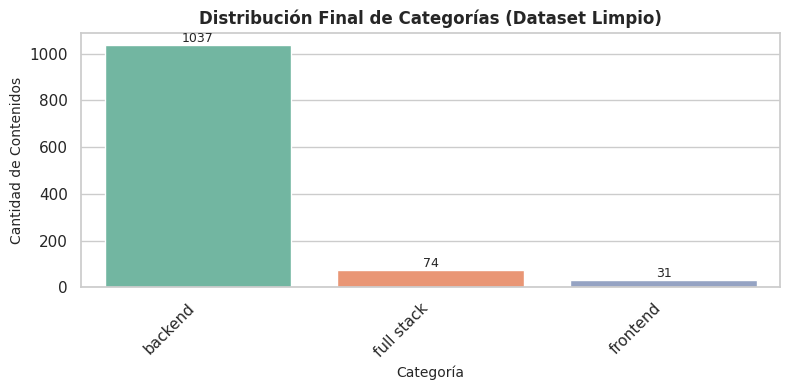

Gráfico de distribución final de categorías generado.


In [ ]:
print("Generando gráfico: Distribución final de CATEGORÍAS...")

# 1. Unir los arreglos de numpy de Train y Test
y_cat_completo_encoded = np.concatenate([y_cat_train, y_cat_test])

# 2. Decodificar los IDs numéricos a sus nombres de texto originales
y_cat_nombres = le_categoria.inverse_transform(y_cat_completo_encoded)

# 3. Contar frecuencias
conteo_cat_final = pd.Series(y_cat_nombres).value_counts()

# 4. Graficar
plt.figure(figsize=(8, 4))
grafico_cat_final = sns.barplot(
    x=conteo_cat_final.index,
    y=conteo_cat_final.values,
    hue=conteo_cat_final.index,
    palette="Set2",
    legend=False
)


# GRÁFICO 7. Distribución de categorías
plt.title("Distribución Final de Categorías (Dataset Limpio)", fontsize=12, fontweight='bold')
plt.xlabel("Categoría", fontsize=10)
plt.ylabel("Cantidad de Contenidos", fontsize=10)
plt.xticks(rotation=45, ha='right')

for barra in grafico_cat_final.patches:
    if barra.get_height() > 0:
        grafico_cat_final.annotate(
            f'{int(barra.get_height())}',
            (barra.get_x() + barra.get_width() / 2., barra.get_height()),
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.show()
print("Gráfico de distribución final de categorías generado.")

Generando grafico: Top 10 LENGUAJES (post-limpieza)...


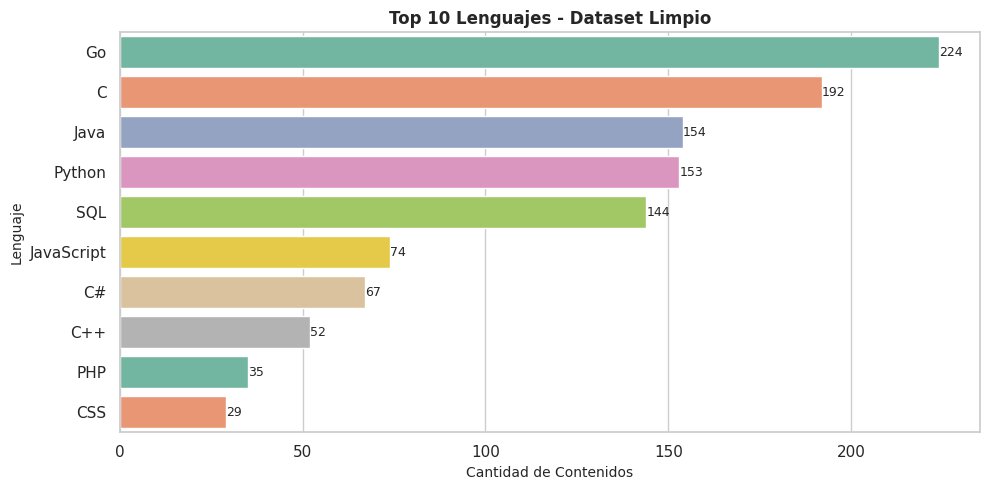

Grafico de lenguajes post-limpieza generado.


In [ ]:
# GRÁFICO 8: Top 10 lenguajes post-limpieza
print("Generando grafico: Top 10 LENGUAJES (post-limpieza)...")

# 1. Recuperar los datos del dataset limpio a partir de los arreglos de Train y Test
y_len_completo_encoded = np.concatenate([y_len_train, y_len_test])
y_len_nombres = le_lenguaje.inverse_transform(y_len_completo_encoded)

# 2. Obtener el Top 10
top_leng_final = pd.Series(y_len_nombres).value_counts().head(10)

# 3. Graficar en formato horizontal
plt.figure(figsize=(10, 5))
grafico_len_final = sns.barplot(
    y=top_leng_final.index,
    x=top_leng_final.values,
    hue=top_leng_final.index,
    palette="Set2",
    legend=False
)

plt.title("Top 10 Lenguajes - Dataset Limpio", fontsize=12, fontweight='bold')
plt.xlabel("Cantidad de Contenidos", fontsize=10)
plt.ylabel("Lenguaje", fontsize=10)

# Anotación para barras horizontales (usando get_width)
for barra in grafico_len_final.patches:
    if barra.get_width() > 0:
        grafico_len_final.annotate(
            f'{int(barra.get_width())}',
            (barra.get_width(), barra.get_y() + barra.get_height() / 2.),
            ha='left', va='center', fontsize=9
        )

plt.tight_layout()
plt.show()
print("Grafico de lenguajes post-limpieza generado.")

In [ ]:
# Reconstrucción de los datos concatenados
y_cat_completo = le_categoria.inverse_transform(np.concatenate([y_cat_train, y_cat_test]))
y_len_completo = le_lenguaje.inverse_transform(np.concatenate([y_len_train, y_len_test]))

# Métrica de total de registros limpios
total_registros_limpios = len(y_cat_completo)

# Clases únicas
categorias_unicas = np.unique(y_cat_completo)
num_lenguajes = len(np.unique(y_len_completo))

print("RESUMEN DE LIMPIEZA DE TEXTOS:")
print(f"   - Registros listos tras filtrado: {total_registros_limpios}")
print(f"   - Categorias disponibles ({len(categorias_unicas)}): {list(categorias_unicas)}")
print(f"   - Lenguajes disponibles:           {num_lenguajes}")
print("==================================================")
print("Dataset consolidado y listo para la fase de modelado.")

RESUMEN DE LIMPIEZA DE TEXTOS:
   - Registros listos tras filtrado: 1142
   - Categorias disponibles (3): ['backend', 'frontend', 'full stack']
   - Lenguajes disponibles:           14
Dataset consolidado y listo para la fase de modelado.


# **4. Entrenamiento y evaluación de los modelos de Machine Learning**




## Entrenamiento de modelos
**PASO 1 - TF-IDF**: Convierte palabras a numeros. Cuenta cuantas veces aparece cada palabra, pero le da menos importancia a palabras muy comunes (como "el", "la", "que").

**PASO 2 - LogisticRegression**: El clasificador. Es el "cerebro" que aprende a asociar ciertas palabras con cada categoria.

In [ ]:
# 1. Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

print("=== ENTRENANDO MODELOS DE MACHINE LEARNING (AUSTERO DE SESGO) ===")

# NOTA: se entrena directamente sobre y_cat_train/y_len_train (ya codificados
# como enteros por el LabelEncoder), no sobre los nombres de texto. Esto hace
# que skl2onnx exporte output_label como int64 y el mapa de probabilidades
# quede indexado por id numerico, que es el contrato que espera el backend
# Java (OnnxModelService decodifica el id via mapa_categoria.json/mapa_lenguaje.json).

# --- MODELO 1: Clasificador de Categorías ---
logging.info("Creando Pipeline para clasificación de CATEGORÍAS...")
pipeline_categoria = Pipeline([
    ('vectorizador', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        stop_words=STOP_WORDS_ESPANOL,
        min_df=2,              # Elimina errores tipográficos y palabras únicas
        sublinear_tf=True
    )),
    ('clasificador', LogisticRegression(
        random_state=42,
        max_iter=1000,
        fit_intercept=False,   # Elimina el sesgo por defecto hacia la clase dominante
        C=1.0,                 # Mantiene la fuerza de confianza alta en casos válidos
        class_weight='balanced'  # Compensa el fuerte desbalance backend/frontend/full stack
    ))
])

In [ ]:
# --- MODELO 2: Clasificador de Lenguajes ---
logging.info("Creando Pipeline para clasificación de LENGUAJES...")
pipeline_lenguaje = Pipeline([
    ('vectorizador', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        stop_words=STOP_WORDS_ESPANOL,
        min_df=2,
        sublinear_tf=True
    )),
    ('clasificador', LogisticRegression(
        random_state=42,
        max_iter=1000,
        fit_intercept=False,   # Elimina el sesgo por defecto hacia la clase dominante
        C=1.0,                 # Mantiene la fuerza de confianza alta en casos válidos
        class_weight='balanced'  # Compensa el fuerte desbalance backend/frontend/full stack
    ))
])

In [ ]:
# --- ENTRENAMIENTO ---
try:
    logging.info("Entrenando el modelo de CATEGORÍAS...")
    pipeline_categoria.fit(X_train, y_cat_train)
    logging.info(" [OK] Modelo de categorías entrenado exitosamente.")

    logging.info("Entrenando el modelo de LENGUAJES...")
    pipeline_lenguaje.fit(X_train, y_len_train)
    logging.info(" [OK] Modelo de lenguajes entrenado exitosamente.")

    logging.info("=== ENTRENAMIENTO FINALIZADO CON ÉXITO ===")

except Exception as e:
    logging.error(f"Error durante el entrenamiento de los modelos: {e}")
    raise e

## Evaluacion de los modelos

Probamos que tan bien aprendieron los modelos con los datos de PRUEBA (el 20% que separamos al inicio y que NUNCA vieron antes).

In [ ]:
print("=== EVALUANDO EL DESEMPENO DE LOS MODELOS ===")

# Las predicciones del pipeline vienen codificadas como enteros (se entreno
# sobre las etiquetas ya codificadas). Se decodifican a nombres de texto con
# los mismos LabelEncoder para el reporte y el resto del analisis.
print("\nRealizando predicciones sobre los datos de prueba...")
predicciones_categoria = le_categoria.inverse_transform(pipeline_categoria.predict(X_test))
predicciones_lenguaje = le_lenguaje.inverse_transform(pipeline_lenguaje.predict(X_test))
print("Predicciones realizadas.")

y_cat_test_eval = le_categoria.inverse_transform(y_cat_test)
y_len_test_eval = le_lenguaje.inverse_transform(y_len_test)

# --- METRICA 1: Accuracy (Precisión General) ---
print("\nMETRICA PRINCIPAL - ACCURACY (Precisión):")

accuracy_cat = accuracy_score(y_cat_test_eval, predicciones_categoria)
accuracy_len = accuracy_score(y_len_test_eval, predicciones_lenguaje)

print(f"\nPrecisión en CATEGORIA: {accuracy_cat * 100:.2f}%")
print(f"   (de {len(y_cat_test_eval)} textos de prueba, acertó {int(accuracy_cat * len(y_cat_test_eval))})")
print(f"Precisión en LENGUAJE:  {accuracy_len * 100:.2f}%")
print(f"   (de {len(y_len_test_eval)} textos de prueba, acertó {int(accuracy_len * len(y_len_test_eval))})")

In [ ]:
# Obtener las clases desde los LabelEncoder (los pipelines se entrenaron con
# etiquetas enteras, asi que pipeline.classifier_.classes_ ya no son nombres)
clases_categoria = le_categoria.classes_
clases_lenguaje = le_lenguaje.classes_

# --- REPORTE CATEGORÍA ---
print("REPORTE DETALLADO - CATEGORÍA:")
print(classification_report(
    y_cat_test_eval,          # Usa tu variable de texto ya creada
    predicciones_categoria,
    labels=clases_categoria,
    zero_division=0
))

# --- REPORTE LENGUAJE ---
print("\nREPORTE DETALLADO - LENGUAJE:")
print(classification_report(
    y_len_test_eval,          # Usa tu variable de texto ya creada
    predicciones_lenguaje,
    labels=clases_lenguaje,
    zero_division=0
))


Generando Matriz de Confusión...


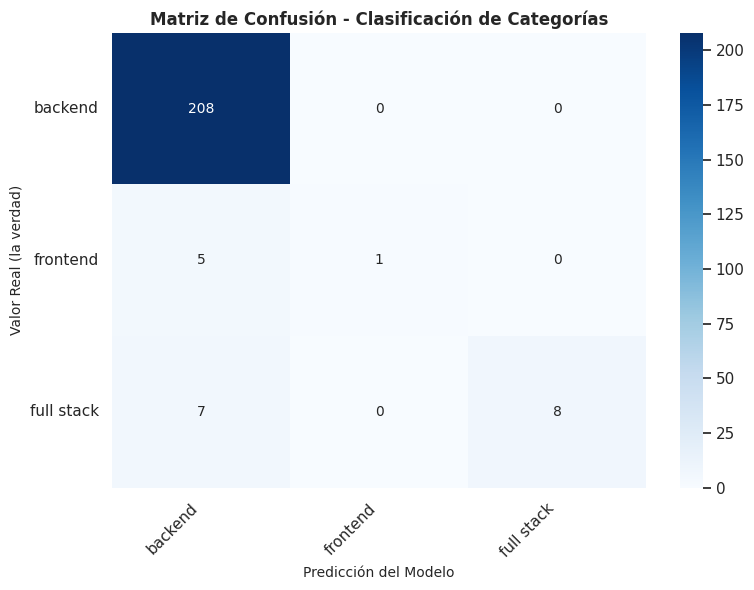

Matriz de confusión generada.


In [ ]:
# GRAFICO 9: Matriz de Confusion
# La matriz de confusion es una tabla que muestra:
# - En las filas: la categoria REAL (la verdad)
# - En las columnas: lo que el modelo PREDIJO
# Los numeros en la diagonal (de esquina a esquina) son ACIERTOS.
# Los numeros fuera de la diagonal son ERRORES.

print("\nGenerando Matriz de Confusión...")

plt.figure(figsize=(8, 6))
matriz_confusion = confusion_matrix(
    y_cat_test_eval,          # Usa tu variable de texto ya creada
    predicciones_categoria,
    labels=clases_categoria
)

sns.heatmap(
    matriz_confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=clases_categoria,
    yticklabels=clases_categoria
)
plt.title("Matriz de Confusión - Clasificación de Categorías", fontweight='bold', fontsize=12)
plt.xlabel("Predicción del Modelo", fontsize=10)
plt.ylabel("Valor Real (la verdad)", fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print("Matriz de confusión generada.")

In [ ]:
# --- Análisis de errores ---
print("\nANÁLISIS DE ERRORES (CATEGORÍAS):")
error_indices = y_cat_test_eval != predicciones_categoria
total_errores = error_indices.sum()

if total_errores > 0:
    errores_df = pd.DataFrame({
        'Texto Limpio': X_test[error_indices].iloc[:3].values,
        'Categoría Real': y_cat_test_eval[error_indices][:3],        # Ya es string, sin inverse_transform
        'Categoría Predicha': predicciones_categoria[error_indices][:3] # Ya es string, sin inverse_transform
    })
    print(f"Se encontraron {total_errores} errores en categorías.")
    print("Mostrando los primeros errores como ejemplo:")
    display(errores_df)
else:
    print("¡No se encontraron errores! El modelo acertó todas las predicciones de prueba.")


ANÁLISIS DE ERRORES (CATEGORÍAS):
Se encontraron 12 errores en categorías.
Mostrando los primeros errores como ejemplo:


,Texto Limpio,Categoría Real,Categoría Predicha
0,html xhtml y css tu plan visual para diseñar páginas web efectivas si alguna vez has sentido curiosidad por cualquiera de los múltiples acrónimos de internet las tecnologías web que representan y cómo pueden beneficiarte este libro es un excelente punto de partida este libro cubre todos los temas necesarios para empezar a funcionar con html xhtml y css ofreciendo a los lectores una guía para el diseño moderno basado en estándares las tareas clave que se abordan en el libro incluyen configurar una página web reducir la resolución de imágenes crear botones de radio añadir un contador de visitas añadir un sonido incrustado añadir contenido de otros sitios como integrar un blog y crear un feed rss los grandes temas se dividen en subtemas más pequeños y accesibles que se explican claramente en dos páginas eliminando el vaivén de páginas que requiere otras referencias organizado de forma que las habilidades se desarrollen progresivamente a lo largo del libro junto con encabezados de página en negrita es fácil de hojear y encontrar fácilmente cualquier sección o tema que busques comprensible con términos sencillos que evitan la jerga intimidante y sin explicación este es un libro que beneficiará tanto a principiantes como a usuarios avanzados aunque se centra principalmente en las tecnologías descritas en el título este libro ofrece consejos para integrarse con google flickr sitios de marcadores sociales e incluso para crear e implementar fuentes rss puedes estar tranquilo cada una de estas tecnologías se explica con los beneficios de cada una descrita un recurso serio que va al grano de forma rápida y concisa este libro te ayuda a adquirir habilidades reales que te harán conectar en poco tiempo lo mejor de todo es que puedes estar seguro de que lo estás haciendo correctamente html xhtml y css tu plano visual para diseñar páginas web efectivas ofrece a los aprendices visuales una referencia sólida que emplea ejemplos directos para enseñarte a crear y diseñar páginas web con impacto las barras laterales aplica y extra destacan consejos útiles y capturas de pantalla en alta resolución ilustran claramente cada tarea mientras que explicaciones concisas te guían por los ejemplos el sitio web asociado contiene todo el código necesario para aprender html,frontend,backend
1,javascript orientado a objetos aprende todo lo que necesitas saber sobre javascript orientado a objetos con esta guía completa entra en el mundo del desarrollo de vanguardia acerca de este libro este libro ha sido actualizado para cubrir todas las nuevas funciones orientadas a objetos introducidas en ecmascript 6 hace que la programación orientada a objetos sea accesible y comprensible para desarrolladores web escribe código javascript mejor y más fácil de mantener mientras exploras ejemplos interactivos que pueden usarse en tus propios scripts para quién es este libro este libro es ideal para desarrolladores javascript nuevos o intermedios que quieren prepararse para problemas de desarrollo web resueltos por orientado a objetos javascript lo que aprenderás aplica lo básico de la programación orientada a objetos en el entorno javascript usa una consola de javascript con dominio total haz tus programas más limpios rápidos y compatibles con otros programas y bibliotecas familiarízate con iteradores y generadores las nuevas funciones añadidas en es6 infórmate sobre las funciones arrow de ecmascript 6 y hazlas tuyas propias entiende los objetos en las herramientas de desarrollo de google chrome y cómo usarlas utiliza una mezcla de herencia prototipal y copiar propiedades en tu flujo de trabajo aplicar técnicas de programación reactiva mientras se codifica en javascript en detalle javascript es un lenguaje de programación orientado a objetos que se utiliza para el desarrollo de sitios web las páginas web desarrolladas hoy en día siguen actualmente un paradigma que tiene tres partes claramente distinguibles contenido html presen

# **5. Serialización del modelo**

"Serializar" significa guardar el modelo en un archivo para poder usarlo despues sin tener que volver a entrenarlo.

Exportamos en **DOS formatos**:
1. **.joblib** -> Para pruebas locales y desarrollo en Python
2. **.onnx**  -> Para produccion en Java/Spring Boot (formato portable)

**¿Por que ONNX?**
El equipo de Backend usa Java con Spring Boot. Con el formato ONNX pueden cargar el modelo directamente con onnxruntime (libreria de Microsoft) sin necesidad de tener Python corriendo en produccion. Esto evita un microservicio Python separado, reduce latencia y simplifica el despliegue en OCI.

In [ ]:
print("SERIALIZACION - EXPORTANDO MODELOS ENTRENADOS")
print("(Entregable para el equipo de Backend)")

# ==============================================================================
# EXPORTAR ARTEFACTOS PARA BACKEND (ONNX + MAPAS JSON)
# ==============================================================================
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger("ExportadorONNX")

SALIDA_DIR = Path("artifacts")

# Cada entrada es (pipeline entrenado, LabelEncoder correspondiente). El
# LabelEncoder es necesario porque los pipelines se entrenaron con etiquetas
# enteras (no nombres), y es la unica fuente confiable para reconstruir el
# mapa id -> nombre real de la categoria/lenguaje.
MODELOS_A_EXPORTAR = {
    "categoria": (pipeline_categoria, le_categoria),
    "lenguaje": (pipeline_lenguaje, le_lenguaje)
}

def exportar_para_backend(modelos_dict: dict, directorio: Path) -> None:
    """Exporta unicamente los modelos ONNX y sus correspondientes mapas JSON."""
    directorio.mkdir(parents=True, exist_ok=True)

    # 1. Forma de entrada esperada por el backend Java: vector 1D de strings
    # (OnnxTensor.createTensor(environment, String[]) crea un tensor rank-1,
    # con nombre "input" -- debe coincidir exactamente con OnnxModelService.java).
    tipos_entrada = [('input', StringTensorType([None]))]

    for nombre, (pipeline, label_encoder) in modelos_dict.items():

        # 2. Mapa de clases: id entero (orden del LabelEncoder) -> nombre real
        mapa_clases = {int(idx): str(clase) for idx, clase in enumerate(label_encoder.classes_)}
        ruta_json = directorio / f"mapa_{nombre}.json"

        with open(ruta_json, "w", encoding="utf-8") as f:
            json.dump(mapa_clases, f, ensure_ascii=False, indent=2)
        logger.info(f"[OK] JSON generado: {ruta_json.name}")

        # 3. Convertir y guardar Modelo ONNX
        try:
            onnx_model = convert_sklearn(
                pipeline,
                initial_types=tipos_entrada,
                target_opset=12  # Asegura compatibilidad estándar con onnxruntime en backend
            )

            ruta_onnx = directorio / f"modelo_{nombre}.onnx"
            with open(ruta_onnx, "wb") as f:
                f.write(onnx_model.SerializeToString())

            size_kb = ruta_onnx.stat().st_size / 1024
            logger.info(f"[OK] ONNX generado: {ruta_onnx.name} ({size_kb:.1f} KB)")
        except Exception as e:
            logger.error(f"Error al exportar ONNX para '{nombre}': {e}")
            raise

    logger.info(f"\n¡Listo para entregar a Backend en ./{directorio}/!")

# Ejecución
exportar_para_backend(MODELOS_A_EXPORTAR, SALIDA_DIR)


## *Prueba de funcionamiento del modelo*

In [ ]:
# ==============================================================================
# PRUEBA RÁPIDA DE INFERENCIA ONNX CON DETECCIÓN DE PALABRAS CLAVE
# ==============================================================================

import json
import re
from pathlib import Path
import numpy as np
import onnxruntime as ort

# 1. Cargar la sesión del modelo ONNX de LENGUAJE
ruta_modelo_onnx = "artifacts/modelo_lenguaje.onnx"
session = ort.InferenceSession(ruta_modelo_onnx)

# Obtener nombres de las entradas y salidas del modelo ONNX
nombre_entrada = session.get_inputs()[0].name
nombre_salida_label = session.get_outputs()[0].name
nombre_salida_probs = session.get_outputs()[1].name

# 2. Cargar el mapa de normalización de lenguajes para extracción de palabras clave
ruta_mapa_norm = Path("artifacts/mapa_normalizacion_lenguaje.json")

if ruta_mapa_norm.exists():
    with open(ruta_mapa_norm, "r", encoding="utf-8") as f:
        mapa_normalizacion = json.load(f)
else:
    # Fallback por si ejecutas el script de forma aislada
    mapa_normalizacion = {
        "c": "C",
        "c++": "C++",
        "cpp": "C++",
        "c#": "C#",
        "csharp": "C#",
        "css": "CSS",
        "go": "Go",
        "golang": "Go",
        "haskell": "Haskell",
        "html": "HTML",
        "java": "Java",
        "javascript": "JavaScript",
        "js": "JavaScript",
        "matlab": "MATLAB",
        "perl": "Perl",
        "php": "PHP",
        "python": "Python",
        "py": "Python",
        "sql": "SQL",
        "typescript": "TypeScript",
        "ts": "TypeScript",
    }


def extraer_palabras_clave_lenguaje(texto: str, mapa: dict) -> list:
    """Extrae qué lenguajes/alias están explícitamente presentes en el texto."""
    texto_limpio = texto.lower()
    lenguajes_encontrados = set()

    # Ordenar por longitud descendente para evaluar 'c++' o 'c#' antes que 'c'
    aliases_ordenados = sorted(mapa.keys(), key=len, reverse=True)

    for alias in aliases_ordenados:
        alias_escapado = re.escape(alias)
        # Regex que respeta símbolos como +, #
        pattern = (
            r"(?<![a-zA-Z0-9_\+#])" + alias_escapado + r"(?![a-zA-Z0-9_\+#])"
        )

        if re.search(pattern, texto_limpio):
            lenguajes_encontrados.add(mapa[alias])
            # Reemplazar para evitar que 'c' haga match dentro de 'c++'
            texto_limpio = re.sub(pattern, " ", texto_limpio)

    return list(lenguajes_encontrados)


def simular_respuesta_backend(texto: str, umbral: float = 0.50) -> dict:
    """Ejecuta el modelo ONNX y extrae las palabras clave del texto."""
    # A. Inferencia con el modelo ONNX
    input_data = np.array([[texto]], dtype=object)
    outputs = session.run(
        [nombre_salida_label, nombre_salida_probs], {nombre_entrada: input_data}
    )

    prediccion_clase = outputs[0][0]
    dict_probabilidades = outputs[1][0]
    probabilidad_maxima = dict_probabilidades.get(prediccion_clase, 0.0)

    # B. Extracción de palabras clave encontradas en el texto
    palabras_clave_detectadas = extraer_palabras_clave_lenguaje(
        texto, mapa_normalizacion
    )

    # C. Estructura de respuesta con Umbral
    if probabilidad_maxima < umbral:
        return {
            "estado": "⚠️ NO SE PUDO CLASIFICAR CON CERTEZA",
            "probabilidad_maxima": f"{probabilidad_maxima:.2%}",
            "clase_sugerida": prediccion_clase,
            "palabras_clave_encontradas": palabras_clave_detectadas,
            "texto_evaluado": texto,
        }
    else:
        return {
            "estado": "✅ CLASIFICACIÓN EXITOSA",
            "lenguaje_predicho": prediccion_clase,
            "probabilidad": f"{probabilidad_maxima:.2%}",
            "palabras_clave_encontradas": palabras_clave_detectadas,
            "texto_evaluado": texto,
        }


# ==============================================================================
# BATERÍA DE PRUEBAS
# ==============================================================================

casos_de_prueba = [
    # 1. Textos válidos del dominio
    "Crear un servidor web con Node.js, express y javascript",
    "Optimizar una consulta SQL con JOINs y clausula WHERE en Python",
    "Desarrollar un sistema embebido en C++ y C#",
    # 2. Textos fuera de dominio / Basura
    "asdfghj 123456 qwerty pizza tacos",
    "El perro camina por el parque en una tarde calurosa",
    # 3. Texto mixto con alias (js, py)
    "qwerty zzz py xknv 999 js c++",
]

print("=== RESULTADOS DE LA PRUEBA DE LENGUAJES Y PALABRAS CLAVE ===\n")
for texto in casos_de_prueba:
    res = simular_respuesta_backend(texto, umbral=0.50)
    print(f"Input: '{res['texto_evaluado']}'")
    print(f"Estado: {res['estado']}")

    if "lenguaje_predicho" in res:
        print(
            f"Lenguaje Predicho (ONNX): {res['lenguaje_predicho']} (Confianza: {res['probabilidad']})"
        )
    else:
        print(
            f"Confianza insuficiente ({res['probabilidad_maxima']}) < 50.00% | Sugerido: {res['clase_sugerida']}"
        )

    # Mostrar las palabras clave explícitas que leyó del texto
    kw = res["palabras_clave_encontradas"]
    print(
        f"Palabras Clave Detectadas en Texto: {kw if kw else 'Ninguna encontrada'}"
    )

    print("-" * 65)

=== RESULTADOS DE LA PRUEBA DE LENGUAJES Y PALABRAS CLAVE ===

Input: 'Crear un servidor web con Node.js, express y javascript'
Estado: ✅ CLASIFICACIÓN EXITOSA
Lenguaje Predicho (ONNX): JavaScript (Confianza: 67.84%)
Palabras Clave Detectadas en Texto: ['JavaScript']
-----------------------------------------------------------------
Input: 'Optimizar una consulta SQL con JOINs y clausula WHERE en Python'
Estado: ⚠️ NO SE PUDO CLASIFICAR CON CERTEZA
Confianza insuficiente (48.81%) < 50.00% | Sugerido: Python
Palabras Clave Detectadas en Texto: ['Python', 'SQL']
-----------------------------------------------------------------
Input: 'Desarrollar un sistema embebido en C++ y C#'
Estado: ⚠️ NO SE PUDO CLASIFICAR CON CERTEZA
Confianza insuficiente (11.30%) < 50.00% | Sugerido: Go
Palabras Clave Detectadas en Texto: ['C#', 'C++']
-----------------------------------------------------------------
Input: 'asdfghj 123456 qwerty pizza tacos'
Estado: ⚠️ NO SE PUDO CLASIFICAR CON CERTEZA
Confianza 

## Descargar los modelos

Ejecuta la siguiente celda para descargar los archivos generados a tu computadora.

In [ ]:
logger = logging.getLogger("ExportadorML")

def descargar_artefactos_zip(directorio_artifacts: Path, nombre_zip: str = "artefactos_ml") -> None:
    """
    Comprime la carpeta de artefactos y desencadena la descarga de un único archivo .zip.
    """
    if not directorio_artifacts.exists() or not any(directorio_artifacts.iterdir()):
        logger.error(f"El directorio '{directorio_artifacts}' está vacío o no existe.")
        return

    # 1. Crear el archivo ZIP a partir de la carpeta artifacts
    archivo_zip = shutil.make_archive(nombre_zip, 'zip', directorio_artifacts)
    ruta_zip = Path(archivo_zip)

    size_mb = ruta_zip.stat().st_size / (1024 * 1024)
    logger.info(f" [OK] Archivo comprimido generado: {ruta_zip.name} ({size_mb:.2f} MB)")

    # 2. Descargar el ZIP completo
    logger.info("Iniciando descarga en el navegador...")
    files.download(str(ruta_zip))

# Ejecución de la descarga
descargar_artefactos_zip(SALIDA_DIR)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## *Resumen de entregables*

1. Reportes y Validación de Data Science
* Análisis Exploratorio de Datos (EDA): Gráficos de distribución de categorías y lenguajes (consultar celdas anteriores del cuaderno).

* Métricas de Desempeño: Reportes de clasificación (Accuracy, Precision, Recall, F1-Score) y Matrices de Confusión para ambos modelos.

2. Artefactos de Modelos (Pipelines)
* modelo_categoria.joblib / modelo_lenguaje.joblib: Pipelines completos de Scikit-Learn (TF-IDF + Clasificador) para pruebas locales y validación rápida en entornos Python.

* modelo_categoria.onnx / modelo_lenguaje.onnx: Artefactos en formato estándar ONNX para producción (consumo nativo en Java / Spring Boot con onnxruntime).

3. Artefactos de Decodificación y Metadatos (Requeridos por Backend)
encoder_categoria.joblib / encoder_lenguaje.joblib: Instancias de LabelEncoder guardadas para Python.

* mapa_categoria.json / mapa_lenguaje.json: Diccionarios estructurados { "id": "etiqueta" } que permiten a Backend mapear el entero devuelto por el modelo ONNX a su representación en texto original.

* metadata.json: Registro de trazabilidad de MLOps con la versión de scikit-learn, soporte ONNX, fecha de generación y lista completa de clases.

Nota: Los modelos en formato ONNX serán utilizados por el backend en Java/Spring Boot mediante ONNX Runtime, permitiendo realizar inferencias sin depender de un microservicio en Python.